In [ ]:

import os, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
N_SPLITS = 5
EPOCHS = 200
BATCH_SIZE = 128
PATIENCE = 10

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)
print(tf.__version__)


2.19.0


In [ ]:

# Load the dataset
df = pd.read_csv("https://raw.githubusercontent.com/McahitKutsal/hivcsv/main/HIV7.csv")

# Target variable
y = df["HIV_active"].values

# Select numeric columns
X = df.drop(columns=["HIV_active"])
X = X.select_dtypes(include=["float64", "int64"]).values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class distribution:", pd.Series(y).value_counts().to_dict())


X shape: (2885, 1)
y shape: (2885,)
Class distribution: {1: 1473, 0: 1412}


In [ ]:

def build_cnn_model(input_dim):
    # Based on the simplified CNN architecture in the PDF
    model = models.Sequential([
        layers.Input(shape=(input_dim, 1)),
        layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        layers.GlobalMaxPooling1D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.15),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model


In [ ]:

def evaluate_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
    }

def plot_avg_training_history(all_histories, max_epoch=None):
    if not all_histories:
        return

    keys = ["loss", "val_loss", "accuracy", "val_accuracy", "auc", "val_auc"]
    avg_history = {}

    if max_epoch is None:
        max_epoch = max(len(h["loss"]) for h in all_histories)

    for key in keys:
        padded = []
        for h in all_histories:
            vals = h.get(key, [])
            if len(vals) < max_epoch:
                vals = vals + [vals[-1]] * (max_epoch - len(vals))
            else:
                vals = vals[:max_epoch]
            padded.append(vals)
        avg_history[key] = np.mean(np.array(padded), axis=0)

    plt.figure(figsize=(8,5))
    plt.plot(avg_history["accuracy"], label="Train Acc")
    plt.plot(avg_history["val_accuracy"], label="Val Acc")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("CNN Average Accuracy across 5 folds")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8,5))
    plt.plot(avg_history["loss"], label="Train Loss")
    plt.plot(avg_history["val_loss"], label="Val Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("CNN Average Loss across 5 folds")
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:

def run_cnn_5fold(X, y, n_splits=5, seed=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    fold_results = []
    all_histories = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        print("\n" + "="*30)
        print(f"FOLD {fold}/{n_splits}")
        print("="*30)

        set_seed(seed + fold)

        X_train_full, X_test = X[train_idx], X[test_idx]
        y_train_full, y_test = y[train_idx], y[test_idx]

        X_train, X_val, y_train, y_val = train_test_split(
            X_train_full, y_train_full,
            test_size=0.2,
            random_state=seed + fold,
            stratify=y_train_full
        )

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)
        X_test = scaler.transform(X_test)

        X_train_cnn = X_train[..., np.newaxis]
        X_val_cnn = X_val[..., np.newaxis]
        X_test_cnn = X_test[..., np.newaxis]

        class_weights = compute_class_weight(
            class_weight="balanced",
            classes=np.unique(y_train),
            y=y_train
        )
        cw = dict(enumerate(class_weights))

        model = build_cnn_model(X_train.shape[1])

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True
        )

        history = model.fit(
            X_train_cnn, y_train,
            validation_data=(X_val_cnn, y_val),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[early_stop],
            class_weight=cw,
            verbose=0
        )

        all_histories.append(history.history)

        y_prob = model.predict(X_test_cnn, verbose=0).ravel()
        metrics = evaluate_metrics(y_test, y_prob, threshold=0.5)
        metrics["fold"] = fold
        metrics["epochs_ran"] = len(history.history["loss"])
        fold_results.append(metrics)

        print({
            "accuracy": round(metrics["accuracy"], 4),
            "precision": round(metrics["precision"], 4),
            "recall": round(metrics["recall"], 4),
            "f1": round(metrics["f1"], 4),
            "roc_auc": round(metrics["roc_auc"], 4),
            "epochs_ran": metrics["epochs_ran"]
        })

    results_df = pd.DataFrame(fold_results)

    summary = {}
    metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc"]
    for col in metric_cols:
        summary[col] = {
            "mean": results_df[col].mean(),
            "std": results_df[col].std(ddof=1),
            "var": results_df[col].var(ddof=1),
            "formatted": f"{results_df[col].mean():.4f} ± {results_df[col].std(ddof=1):.4f}"
        }

    return results_df, summary, all_histories


In [ ]:

results_df, summary, all_histories = run_cnn_5fold(X, y, n_splits=N_SPLITS, seed=SEED)

print("\nFold-wise results:")
display(results_df)

summary_rows = []
for metric_name, vals in summary.items():
    summary_rows.append({
        "Metric": metric_name.upper(),
        "Mean": vals["mean"],
        "Std": vals["std"],
        "Variance": vals["var"],
        "Formatted": vals["formatted"]
    })

summary_df = pd.DataFrame(summary_rows)
print("\nSummary results:")
display(summary_df)

results_df.to_csv("CNN_fold_results.csv", index=False)
summary_df.to_csv("CNN_summary_results.csv", index=False)

print("\nSaved files:")
print("- CNN_fold_results.csv")
print("- CNN_summary_results.csv")



FOLD 1/5
{'accuracy': 0.4991, 'precision': 0.5068, 'recall': 0.6361, 'f1': 0.5641, 'roc_auc': np.float64(0.534), 'epochs_ran': 11}

FOLD 2/5
{'accuracy': 0.5095, 'precision': 0.5169, 'recall': 0.5714, 'f1': 0.5428, 'roc_auc': np.float64(0.51), 'epochs_ran': 13}

FOLD 3/5
{'accuracy': 0.5286, 'precision': 0.537, 'recall': 0.5661, 'f1': 0.5512, 'roc_auc': np.float64(0.5218), 'epochs_ran': 11}

FOLD 4/5
{'accuracy': 0.4991, 'precision': 0.5086, 'recall': 0.6, 'f1': 0.5505, 'roc_auc': np.float64(0.4903), 'epochs_ran': 11}

FOLD 5/5
{'accuracy': 0.4939, 'precision': 0.5052, 'recall': 0.4915, 'f1': 0.4983, 'roc_auc': np.float64(0.4997), 'epochs_ran': 51}

Fold-wise results:


,accuracy,precision,recall,f1,roc_auc,fold,epochs_ran
0,0.499133,0.506775,0.636054,0.564103,0.534026,1,11
1,0.509532,0.516923,0.571429,0.542811,0.509964,2,13
2,0.528596,0.536977,0.566102,0.551155,0.521842,3,11
3,0.499133,0.508621,0.600000,0.550544,0.490251,4,11
4,0.493934,0.505226,0.491525,0.498282,0.499675,5,51



Summary results:


,Metric,Mean,Std,Variance,Formatted
0,ACCURACY,0.506066,0.013811,0.000191,0.5061 ± 0.0138
1,PRECISION,0.514905,0.013139,0.000173,0.5149 ± 0.0131
2,RECALL,0.573022,0.053369,0.002848,0.5730 ± 0.0534
3,F1,0.541379,0.025275,0.000639,0.5414 ± 0.0253
4,ROC_AUC,0.511152,0.017374,0.000302,0.5112 ± 0.0174



Saved files:
- CNN_fold_results.csv
- CNN_summary_results.csv


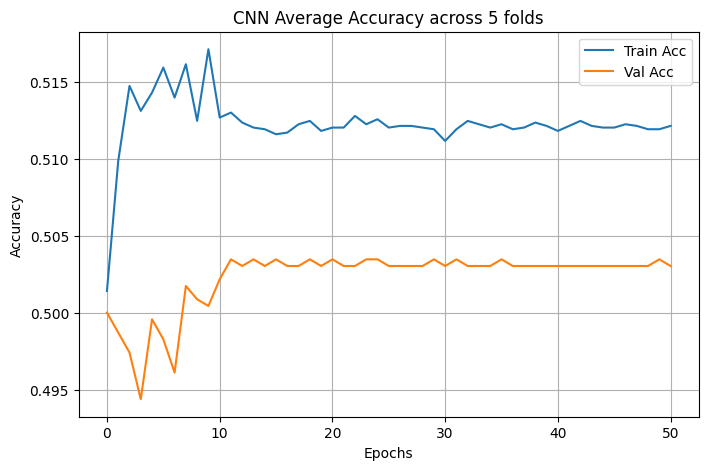

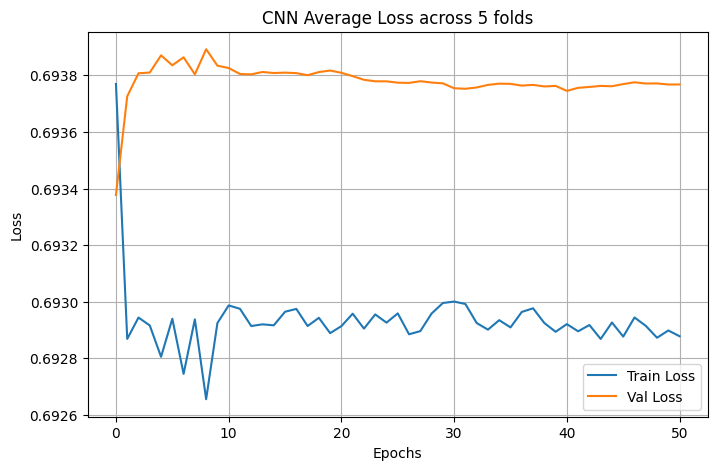

In [ ]:

plot_avg_training_history(all_histories)
